# Introduction
As we have completed a preprocessing pipeline, it is now time to select a model, perform feature 
tuning, and perform hyperparameter tunining. We will measure models on the following metrics:
- Precision (focused, it is more crucial to be correct than to flag all spam)
- Recall
- ROC Curve
- Accuracy

## Setup

In [ ]:
# use this cell to install all requirements for this project.
# !pip install -r requirements.txt

In [3]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
# make array print readable
np.set_printoptions(suppress=True, precision=4)

In [5]:
df = pd.read_csv(
    'data/cleaned_emails.csv', 
    index_col='filename', )
df.head()

,body,from,weekday,day,month,year,hour,timezone,to,subject,return_path,received,delivered_to,message_id,spam
filename,,,,,,,,,,,,,,,
01128.efb36914ecb55d78a894591eff0843c5,"['on', 'sun', 'NUMBER', 'jul', 'NUMBER', 'NUMB...",uni.de,sun,21,jul,2002,20,-400.0,freshrpms.net,"['re', 'ximian', 'apt', 'repo']",freshrpms.net,7,1,uni.de,False
00659.02e6dd777f837798533eae8f3b6a0491,"['what', 'is', 'mime', 'mime', 'stand', 'for',...",docserver.cac.washington.edu,mon,19,aug,2002,23,-700.0,example.sourceforge.net,"['wm', 'the', 'mime', 'inform', 'you', 'reques...",example.sourceforge.net,6,1,docserver.cac.washington.edu,False
00776.7df92458e9cf04b8873c406bde7d2fbe,"['im', 'not', 'up', 'to', 'fork', 'the', 'text...",golux.com,tue,13,aug,2002,15,-400.0,xent.com,"['a', 'messag', 'for', 'our', 'time']",xent.com,6,2,golux.com,False
00116.409b29c26edef06268b4bfa03ef1367a,"['on', 'sat', 'jul', 'NUMBER', 'NUMBER', 'at',...",skynet.ie,sat,20,jul,2002,13,100.0,linux.ie,"['re', 'ilug', 'vanquish', 'the', 'daemon', 'o...",linux.ie,8,1,skynet.ie,False
00615.23556d88fcb1179b25083cfc41017f42,"['origin', 'messag', 'date', 'thu', 'NUMBER', ...",dmv.com,thu,8,aug,2002,16,-400.0,example.sourceforge.net,"['re', 'razorus', 'use', 'razor', 'with', 'non...",example.sourceforge.net,7,1,landshark,False


In [6]:
# import feature pipeline
import cloudpickle as cp

feature_pipeline = None
with open('objects/feature_pipeline.pkl', 'rb') as f:
    feature_pipeline = cp.load(f)

In [7]:
# creating train-test split
from sklearn.model_selection import train_test_split

X = df.drop('spam', axis=1)
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

print(X_train.head(1))
print()
print(y_train.head(1))

                                                                                     body  \
filename                                                                                    
00876.668b933f0dcc4bbbc7bad7255ba2d659  ['unless', 'your', 'parent', 'were', 'select',...   

                                              from weekday  day month  year  \
filename                                                                      
00876.668b933f0dcc4bbbc7bad7255ba2d659  silcom.com     wed   24   jul  2002   

                                        hour  timezone  \
filename                                                 
00876.668b933f0dcc4bbbc7bad7255ba2d659    17    -700.0   

                                                            to  \
filename                                                         
00876.668b933f0dcc4bbbc7bad7255ba2d659  spamassassin.taint.org   

                                                                                  subject  \
filename       

# Model Selection
Here, we will perform cross-validation on a variety of different models using standard parameters.
Given our current data set of scaled variables, linear models seem promising to creating a great
classifier. Models like Decision Trees, however, may struggle due to our number of features and due
to the use of cyclical encoding. We will test our data against the following models:
- Logistic Regression
- Stochastic Gradient Descent
- Support Vector Machines
- RandomForestClassifiers

In [8]:
from sklearn.model_selection import cross_val_predict, cross_val_score

def test_model(pipe, cv=5, scoring='f1'):
    
    print('~ CROSS VALIDATION SCORES ~\n')
    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        verbose=3,
        n_jobs=4
    )

    print(cv_scores)
    print(f'mean {scoring} score: {np.mean(cv_scores)}')

feature_pipeline.verbose = False

## Logistic Regression

In [9]:
# create logistic regression pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_clf_pipeline = Pipeline([
    ('trans', feature_pipeline),
    ('log_clf', LogisticRegression())
])


test_model(log_clf_pipeline)

~ CROSS VALIDATION SCORES ~



[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    3.5s remaining:    5.3s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.952) total time=   1.2s
[0.9618 0.9412 0.9623 0.9471 0.9515]
mean f1 score: 0.9527917248380742


[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    4.8s finished


## SGDClassifier

In [10]:
from sklearn.linear_model import SGDClassifier

sgd_clf_pipeline = Pipeline([
    ('trans', feature_pipeline),
    ('sgd_clf', SGDClassifier())
])

test_model(sgd_clf_pipeline)

~ CROSS VALIDATION SCORES ~

[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_c

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.4s remaining:    2.1s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.965) total time=   1.3s
[0.9643 0.9412 0.9563 0.9518 0.9646]
mean f1 score: 0.9556300436959247


[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished


## Support Vector Machine

In [11]:
from sklearn.svm import SVC

svc_clf_pipeline = Pipeline([
    ('trans', feature_pipeline),
    ('svm_clf', SVC())
])

test_model(svc_clf_pipeline)

~ CROSS VALIDATION SCORES ~

[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_c

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.5s remaining:    2.2s


[CV] END ................................ score: (test=0.940) total time=   1.7s
[CV] END ................................ score: (test=0.971) total time=   1.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.965) total time=   1.6s
[0.9643 0.9399 0.9713 0.9499 0.9652]
mean f1 score: 0.9581125942189453


[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.0s finished


## Random Forest Classifier

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_clf_pipeline = Pipeline([
    ('trans', feature_pipeline),
    ('rf_clf', RandomForestClassifier())
])

test_model(rf_clf_pipeline)

~ CROSS VALIDATION SCORES ~

[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_c

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.8s remaining:    2.7s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.976) total time=   1.5s
[0.9713 0.9604 0.9644 0.9626 0.976 ]
mean f1 score: 0.9669543033266332


[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.3s finished


## Conclusions
Looking at our initial model tests, we have the following data:

| Model | F1 Mean |
|---|---|
| Logistic Regression | 0.9453 |
| SGD Classifier | 0.9432 |
| SVM | 0.9528 |
| Random Forest | 0.9612 |

With these results, we can see our highest performing models. Focusing on the F1-score, we result
with the Random Forest Classifier and SVM at very high scores with our training data. These models, 
off initial training already perform exceptionally, yet a greater amount of fine tuning is beneficial
and will be performed.

# Feature Selection
Filtering our models, it appears that `Logistic Regression` and `Random Forest` are the highest
performing models based on the `F1 score`. Moving forward, we will select the optimal number of
features for a model. Currently, we have around 200+ features being used in our models. To reduce
complexity, we will create a function to automatically select the **k** best features, with **k**
ranging from [1, (max k)], at a unit interval of 10. This function will perform `cross-validation`
at each **k**, and aggregate the scores (`F1 score`) into a mean. After all scores are gathered, we 
can plot the `F1 score` against **k**, and find the elbow of the plot for each classifier.

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif

def find_optimal_k(model, scoring='f1', name=''):
    '''Will use SelectKBest with from [1, {# of features}], with a 10 unit interval. This will 
    perform cross-validation on a given model and plot all k with their corresponding scores.
    
    params:
        **model:** the model used in classification
        **scoring:** the scoring metric used in cross-validation (default='f1')
        '''
    # find maximum possible k
    high = feature_pipeline.fit_transform(X_train).shape[1]
    
    # create range
    k = list(range(0, high + 1, 10))

    # alter min to start at 1
    k[0] += 1 

    scores = []
    
    for i in k:
        # define pipe
        pipe = Pipeline([
            ('trans', feature_pipeline),
            ('feature_selection', SelectKBest(f_classif, k=i)),
            ('model', model)
        ])

        # cross validate with cv=5
        cv_scores = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=5,
            scoring=scoring,
            verbose=3,
            n_jobs=4
        )

        mean = np.mean(cv_scores)
        scores.append(mean)

    sns.lineplot(x=k, y=scores)
    plt.title(f'{name} F1 vs. K')
    plt.xlabel('K')
    plt.ylabel('F1')
    plt.show()

## Logistic Regression

[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    2.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.805) total time=   1.3s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.5s remaining:    2.3s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.852) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.7s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    1.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.878) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    1.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.904) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.4s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    2.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.920) total time=   1.3s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    2.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.931) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    2.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.928) total time=   1.3s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    2.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.933) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.2s remaining:    1.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.933) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.4s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    1.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.937) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    2.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.946) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.2s remaining:    1.8s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.946) total time=   1.3s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    1.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.948) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.4s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    1.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.950) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    1.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.943) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.2s remaining:    1.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.945) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.4s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.4s remaining:    2.1s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.945) total time=   1.4s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.7s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.4s remaining:    2.1s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.948) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    1.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.950) total time=   1.4s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.4s remaining:    2.1s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.949) total time=   1.2s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.4s remaining:    2.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.952) total time=   1.3s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    2.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.952) total time=   1.3s


[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished


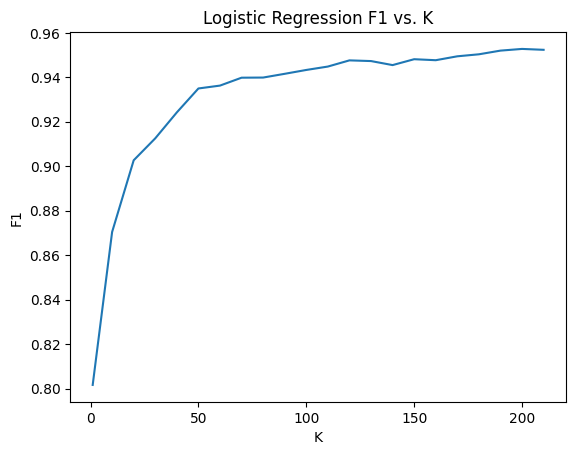

In [14]:
find_optimal_k(LogisticRegression(), name='Logistic Regression')

It appears that the `Logistic Regression` plot has an elbow point around 50, with diminishing
returns beginning around 75. Deciding the optimal **k** at this model involves accuracy-complexity
tradeoff. For minimal complexity, we could use **k**=~75. Or maxmium accuracy, a value of **k**=150.

## Random Forest Classifier

[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.7s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.3s remaining:    2.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.809) total time=   1.3s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    2.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.6s remaining:    2.4s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.946) total time=   1.4s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.7s remaining:    2.5s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.956) total time=   1.4s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.6s remaining:    2.4s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.965) total time=   1.5s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.8s remaining:    2.6s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.963) total time=   1.4s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.2s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.8s remaining:    2.6s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.969) total time=   1.4s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.2s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.6s remaining:    2.5s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.965) total time=   1.4s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.1s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.6s remaining:    2.5s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.967) total time=   1.6s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.2s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.8s remaining:    2.7s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.967) total time=   1.4s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.2s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.9s remaining:    2.8s


[CV] END ................................ score: (test=0.967) total time=   1.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.972) total time=   1.5s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, 

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.3s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.9s remaining:    2.8s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.974) total time=   1.5s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.3s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.3s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    2.1s remaining:    3.1s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.972) total time=   1.7s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.8s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    2.1s remaining:    3.2s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.972) total time=   1.5s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.8s remaining:    2.7s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.972) total time=   1.5s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.2s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.9s remaining:    2.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.967) total time=   1.5s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.4s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    2.2s remaining:    3.2s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.969) total time=   1.6s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.7s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.3s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.3s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    2.2s remaining:    3.3s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.971) total time=   1.6s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.8s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    1.9s remaining:    2.9s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.972) total time=   1.6s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.5s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    2.1s remaining:    3.2s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.965) total time=   1.6s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    2.2s remaining:    3.3s


[CV] END ................................ score: (test=0.961) total time=   2.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.1s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.967) total time=   1.9s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, 

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    4.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   1.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    2.3s remaining:    3.4s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.969) total time=   1.6s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0

[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.8s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.9s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.2s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[Pipel

[Parallel(n_jobs=4)]: Done   2 out of   5 | elapsed:    2.0s remaining:    3.0s


[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.8s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.1s
[Pipeline] .. (step 1 of 2) Processing text_create_list, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing text_sparse, total=   0.0s
[CV] END ................................ score: (test=0.967) total time=   1.6s


[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    3.5s finished


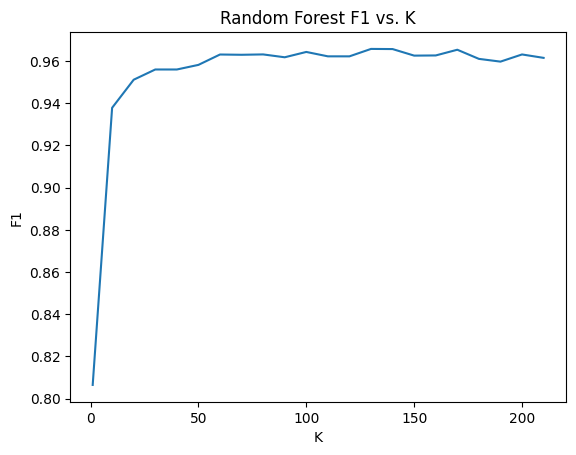

In [15]:
find_optimal_k(RandomForestClassifier(), name='Random Forest')

Now, for the `Random Forest` model, our elbow begins around **k**=25, with diminishing returns
starting at **k**=50. It is much easier to determine an optimal **k** here due to the clear plateau,
accuracy gain for complexity is extremely minimal; therefore the discussion of accuracy-complexity
tradeoff is not as nuanced. We can say that the optimal **k** here is **k**=50.

# Hyperparameter Tuning
After performing *feature selection* on the `Logistic Regression` and `Random Forest` models, we can
conclude that `Random Forest` is a much more optimal classifier to use, due to its superior 
`F1 score` and, after feature selection, low complexity. Next, we will fine-tune our model to boost
performance. We can boost our models performance by performing a randomized search using 
`RandomizedSearchCV` on the following hyperparameters, with their ranges:

| Hyperparameter | Description | Range |
|---|---|---|
| `n_estimators` | Number of trees in the model | 100, 200 |
| `max_depth` | Maximum depth of the tree | None, 10, 20 |
| `max_features` | Max features to consider when splitting a node | sqrt, log2 |
| `min_samples_split` | Minimum number of samples required to split an internal node | 2, 5 |
| `bootstrap` | Whether to use bootstrapping on the tree | True, False |

In [16]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
# optimal k
optimal_k = 50


# define pipeline
rf_pipe = Pipeline([
    ('trans', feature_pipeline),
    ('feature_selection', SelectKBest(f_classif, k=optimal_k)),
    ('rf', RandomForestClassifier())
])

# define param dist.
param_distributions = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__min_samples_split': [2, 5],
    'rf__bootstrap': [True, False]
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=4,
    verbose=10
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5; 1/20] START rf__bootstrap=False, rf__max_depth=10, rf__max_features=log2, rf__min_samples_split=2, rf__n_estimators=200
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing create_path_length, total=   0.0s
[Pipeline] ......... (step 3 of 3) Processing num_scale, total=   0.0s
[Pipeline] ........ (step 1 of 3) Processing cat_impute, total=   0.0s
[Pipeline] ....... (step 2 of 3) Processing cat_ordinal, total=   0.0s
[Pipeline] ...... (step 3 of 3) Processing cat_cyclical, total=   0.0s
[Pipeline] ........ (step 1 of 2) Processing day_impute, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing day_cyclical, total=   0.0s
[CV 2/5; 1/20] START rf__bootstrap=False, rf__max_depth=10, rf__max_features=log2, rf__min_samples_split=2, rf__n_estimators=200
[Pipeline] ........ (step 1 of 3) Processing num_impute, total=   0.0s
[Pipeline]  (step 2 of 3) Processing crea

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf__bootstrap': [True, False], 'rf__max_depth': [None, 10, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used 

In [17]:
model = search.best_estimator_
search.best_score_

np.float64(0.9634416178937064)

# Model Evaluation
After performing a quick `RandomizedSearchCV`, we can now evaluate this model, lets evaluate this
model against our `test` data, and see how it performs on the following metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [22]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, roc_curve, roc_auc_score

# predict X_test

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [71]:
accuracy = sum(y_test == y_pred) / len(y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba[:, 1])

print(f'''
RANDOOM FOREST TEST PREDICTION RESULTS
accuracy............ {accuracy}
precision........... {precision}
recall.............. {recall}
f1.................. {f1}
roc auc............. {roc_auc}''')


RANDOOM FOREST TEST PREDICTION RESULTS
accuracy............ 0.9638752052545156
precision........... 0.9422382671480144
recall.............. 0.9775280898876404
f1.................. 0.9595588235294118
roc auc............. 0.9955702301947127


In [74]:
def plot_precision_recall_curve(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="recall")
    plt.legend()

    plt.xlabel('Threshold of Prediction')
    plt.ylabel('Score')
    plt.title('Random Forest Classifier Precision-Recall Curve')

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--', label='coin flip') # dashed diagonal
    plt.legend()
    
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Random Forest Classifier ROC Curve')

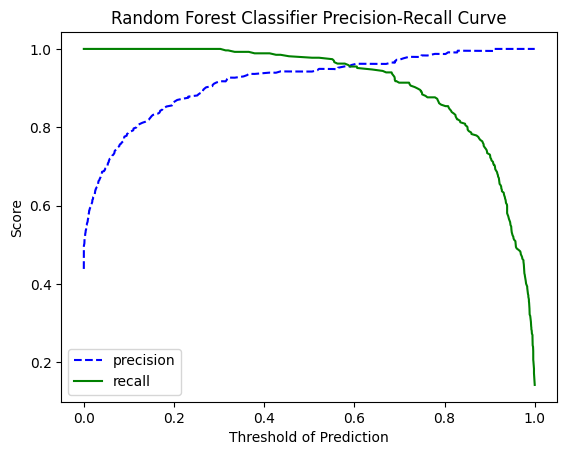

In [68]:
# precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba[:, 1])

plot_precision_recall_curve(precisions, recalls, thresholds)
plt.show()

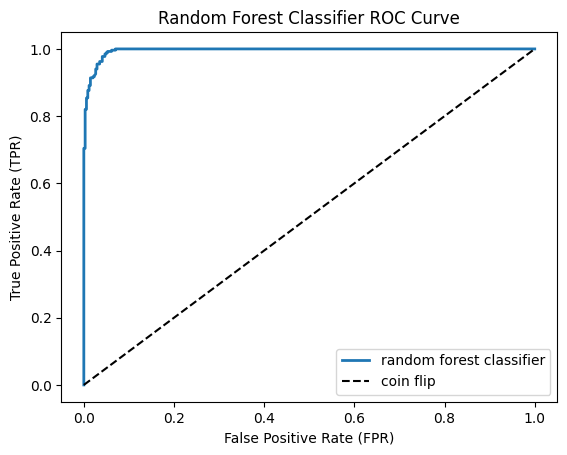

In [76]:
# Reciever Operating Characteristic Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])

plot_roc_curve(fpr, tpr, 'random forest classifier')
plt.show()

# Conclusion
It appears that our model has turned out extremely strong amongst both our training and testing set.
This indicates that our model is not overfit, and generalizes well. With an `f1 score` of `~.96`, 
the `Random Forest Classifier` balances `precision` and `recall` well. An `ROC AUC` score of `.99`
reveals that our model performs very strong across all tresholds. Looking at our `precision-recall` 
curve, we maintain a very acceptable balance between `recall` and `precision`, with the intersection
being at a treshold of `~.6`, with `precision` and `recall` both being around `~.95`.

Overall, we can determine that this spam classifier has turned out to be very successful. All our 
statistics are fairly balanced, yet if we want to bias towards `precision` or `recall`, it is 
absolutely possible to boost a metric, with minimal trade-off.

In [86]:
# finally, save model for reuse.
with open('objects/rf_classifier.pkl', 'wb') as f:
    cp.dump(model, f)